# Deep Learning with PyTorch Step-by-Step: A Beginner's Guide

# Chapter 1

In [1]:
try:
    import google.colab
    import requests
    url = 'https://raw.githubusercontent.com/dvgodoy/PyTorchStepByStep/master/config.py'
    r = requests.get(url, allow_redirects=True)
    open('config.py', 'wb').write(r.content)    
except ModuleNotFoundError:
    pass

from config import *
config_chapter1()
# This is needed to render the plots in this chapter
from plots.chapter1 import *

In [2]:
# 需要导入的库
import numpy as np
from sklearn.linear_model import LinearRegression

import torch
import torch.optim as optim
import torch.nn as nn
from torchviz import make_dot

# 一个简单的回归问题

$$
\Large y = b + w x + \epsilon
$$

## 数据生成

### 生成数据集

In [3]:
true_b = 1
true_w = 2
N = 100

# 生成数据集
np.random.seed(42)
x = np.random.rand(N, 1)
epsilon = (.1 * np.random.randn(N, 1))
y = true_b + true_w * x + epsilon

### Cell 1.1 数据集拆分

In [4]:
# 打乱数据集索引
idx = np.arange(N)
np.random.shuffle(idx)

# 使用前 80% 作为训练集
train_idx = idx[:int(N*.8)]
# 使用剩余索引作为验证集
val_idx = idx[int(N*.8):]

# 生成训练集和验证集
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Generated Data - Train'}, xlabel='x', ylabel='y'>,
        <Axes: title={'center': 'Generated Data - Validation'}, xlabel='x', ylabel='y'>],
       dtype=object))

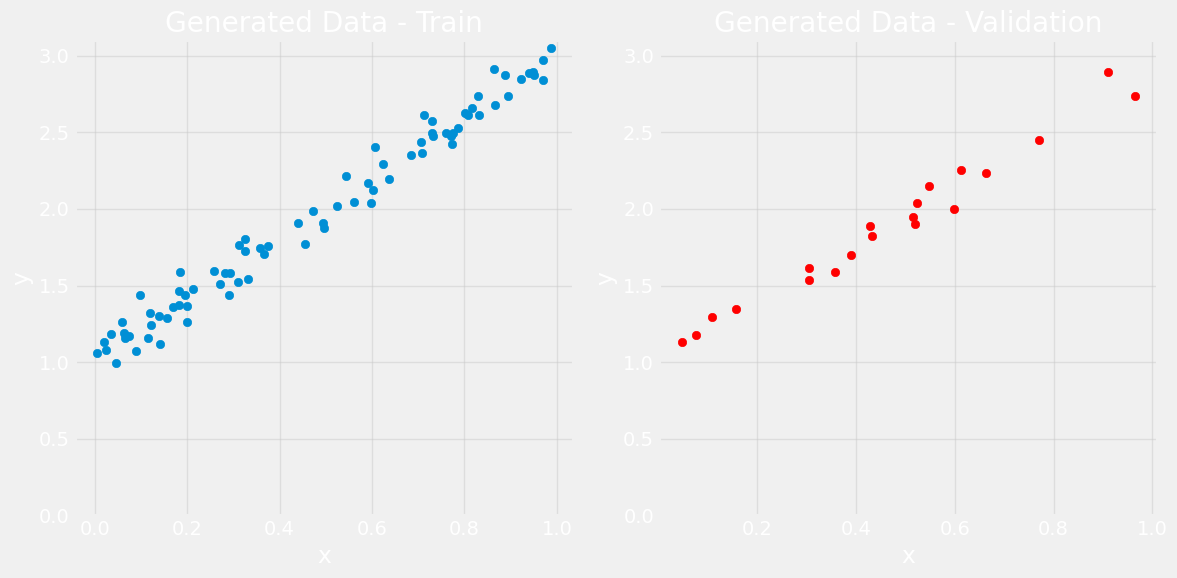

In [5]:
figure1(x_train, y_train, x_val, y_val)

# 梯度下降

## Step 0: 随机初始化

In [6]:
# Step 0 - 随机初始化w和b参数
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)

print(b, w)

[0.49671415] [-0.1382643]


## Step 1: 前向传播计算模型预测输出

In [7]:
# Step 1 - 前向传播计算模型预测输出
yhat = b + w * x_train

## Step 2: 计算损失函数

In [8]:
# Step 2 - 计算损失函数
# We are using ALL data points, so this is BATCH gradient
# descent. How wrong is our model? That's the error!
error = (yhat - y_train)

# It is a regression, so it computes mean squared error (MSE)
loss = (error ** 2).mean()

print(loss)

2.7421577700550976


## Step 3: 计算梯度

In [9]:
# Step 3 - 计算梯度
b_grad = 2 * error.mean()
w_grad = 2 * (x_train * error).mean()
print(b_grad, w_grad)

-3.044811379650508 -1.8337537171510832


## Step 4: 更新参数w和b值

In [10]:
# 设置学习率 - 即 "eta" ~ 类似希腊字母 "n"
lr = 0.1
print(b, w)

# Step 4 - 使用梯度和学习率更新参数
b = b - lr * b_grad
w = w - lr * w_grad

print(b, w)

[0.49671415] [-0.1382643]
[0.80119529] [0.04511107]


## Step 5: 重复以上步骤

In [11]:
# Go back to Step 1 and run observe how your parameters b and w change

# 使用 NumPy 实现线性回归

### Cell 1.2 numpy实现线性回归

In [12]:
# Step 0 - Initializes parameters "b" and "w" randomly
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)

print(b, w)

# 设置学习率 - 即 "eta" ~ 类似希腊字母 "n"
lr = 0.1
# 定义训练轮数 - 即迭代次数
n_epochs = 1000

for epoch in range(n_epochs):
    # Step 1 - 前向传播计算模型预测输出
    yhat = b + w * x_train
    
    # Step 2 - 计算损失
    # We are using ALL data points, so this is BATCH gradient
    # descent. How wrong is our model? That's the error!   
    error = (yhat - y_train)
    # It is a regression, so it computes mean squared error (MSE)
    loss = (error ** 2).mean()
    
    # Step 3 - 计算梯度
    b_grad = 2 * error.mean()
    w_grad = 2 * (x_train * error).mean()

    # Step 4 - 更新参数w和b值
    b = b - lr * b_grad
    w = w - lr * w_grad
    
print(b, w)

[0.49671415] [-0.1382643]
[1.02354094] [1.96896411]


In [13]:
# Sanity Check: 检查结果是否与梯度下降相同
linr = LinearRegression()
linr.fit(x_train, y_train)
print(x_train.shape, y_train.shape)
print(linr.intercept_, linr.coef_[0])

(80, 1) (80, 1)
[1.02354075] [1.96896447]


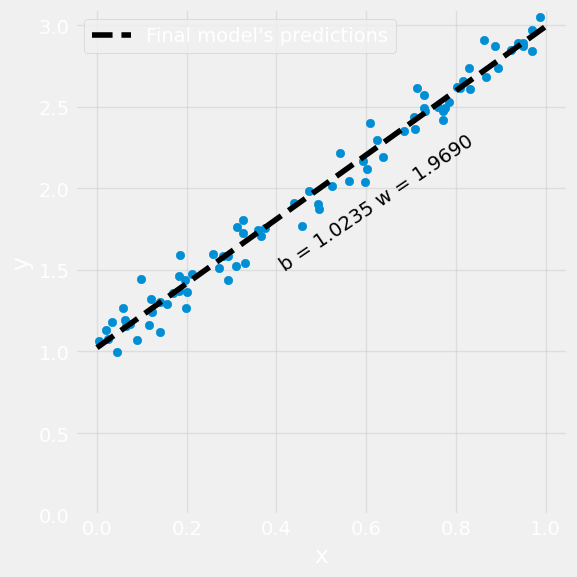

In [14]:
fig = figure3(x_train, y_train)

# PyTorch

## Tensor向量

In [15]:
# pytorch张量创建
scalar = torch.tensor(3.14159)
vector = torch.tensor([1, 2, 3])
matrix = torch.ones((2, 3), dtype=torch.float32)
tensor = torch.randn((2, 3, 4), dtype=torch.float32)

print(scalar)
print(vector)
print(matrix)
print(tensor)

tensor(3.1416)
tensor([1, 2, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[[ 1.4677, -0.4428,  0.6300, -0.1395],
         [ 0.6999,  0.8748, -0.9284, -1.8014],
         [ 1.4081, -1.6832, -0.4589, -1.0234]],

        [[-1.4286, -2.1713,  0.4411,  0.7629],
         [-1.4627, -1.6059,  0.8200, -0.8468],
         [ 0.5407, -0.5197, -2.3996,  0.0832]]])


In [16]:
# 张量的形状

print(tensor.size(), tensor.shape)

torch.Size([2, 3, 4]) torch.Size([2, 3, 4])


In [17]:
# 标量的形状

print(scalar.size(), scalar.shape)

torch.Size([]) torch.Size([])


In [18]:
# 我们得到了一个形状不同的张量，但它仍然是同一个张量

same_matrix = matrix.view(1, 6)
# 尝试改变元素
same_matrix[0, 1] = 2.
# 两个张量都会改变
print(matrix)
print(same_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 2., 1., 1., 1., 1.]])


In [19]:
# 我们可以使用 "new_tensor" 方法来真正复制它到一个新的张量
different_matrix = matrix.new_tensor(matrix.view(1, 6))
# 尝试改变元素
different_matrix[0, 1] = 3.
# 原始张量（矩阵）保持原样！
# 但是我们得到了一个警告，建议使用 "clone()" 方法
print(matrix)
print(different_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 3., 1., 1., 1., 1.]])


C:\Users\a7183\AppData\Local\Temp\ipykernel_36496\708959235.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  different_matrix = matrix.new_tensor(matrix.view(1, 6))


In [20]:
# 我们可以按照 PyTorch 建议使用 "clone" 方法
another_matrix = matrix.view(1, 6).clone().detach()
# 尝试改变元素
another_matrix[0, 1] = 4.
# 原始张量（矩阵）保持原样！
print(matrix)
print(another_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 4., 1., 1., 1., 1.]])


## 加载数据，设备和CUDA

In [21]:
# numpy转为tensor

x_train_tensor = torch.as_tensor(x_train)
x_train.dtype, x_train_tensor.dtype

(dtype('float64'), torch.float64)

In [22]:
# 转为浮点类型

float_tensor = x_train_tensor.float()
float_tensor.dtype

torch.float32

In [23]:
# as_tensor 方法共享基础数据

dummy_array = np.array([1, 2, 3])
dummy_tensor = torch.as_tensor(dummy_array)
# Modifies the numpy array
dummy_array[1] = 0
# Tensor gets modified too...
dummy_tensor

tensor([1, 0, 3], dtype=torch.int32)

In [24]:
# 转为numpy数组

dummy_tensor.numpy()

array([1, 0, 3])

### 定义设备

In [25]:
# 检测设备

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [26]:
# 打印设备信息
n_cudas = torch.cuda.device_count()
for i in range(n_cudas):
    print(torch.cuda.get_device_name(i))

NVIDIA GeForce MX150


In [27]:
# 传输数据

gpu_tensor = torch.as_tensor(x_train).to(device)
gpu_tensor[0]

tensor([0.7713], device='cuda:0', dtype=torch.float64)

### Cell 1.3 加载数据，numpy转为pytorch张量

In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 数据存储在Numpy数组中
# 但需要将它们转换为PyTorch的张量
# 然后将它们发送到所选设备
x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

In [29]:
# 在这里，可以看到差异。请注意，type()更有用
# 因为它还告诉我们张量在哪里(设备)
print(type(x_train), type(x_train_tensor), x_train_tensor.type())

<class 'numpy.ndarray'> <class 'torch.Tensor'> torch.cuda.FloatTensor


In [30]:
# 执行失败
# TypeError: can't convert cuda:0 device type tensor to numpy.
# Use Tensor.cpu() to copy the tensor to host memory first.
# back_to_numpy = x_train_tensor.numpy()

In [31]:
back_to_numpy = x_train_tensor.cpu().numpy()

## 创建参数

In [32]:
# 第一种
# 随机初始化参数b和w,这几乎与在Numpy 中所做的相同
# 因为希望对这些参数应用梯度下降
# 所以需要设置requires_grad=True
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float)
w = torch.randn(1, requires_grad=True, dtype=torch.float)
print(b, w)

tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


In [33]:
# 第二种
# 但是如果想在GPU上运行它怎么办?可以将它们发送到设备，对吗?
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float).to(device)
w = torch.randn(1, requires_grad=True, dtype=torch.float).to(device)
print(b, w)
# Sorry, but NO! The to(device) "shadows" the gradient...
# to(device) 会隐藏梯度


tensor([0.3367], device='cuda:0', grad_fn=<ToCopyBackward0>) tensor([0.1288], device='cuda:0', grad_fn=<ToCopyBackward0>)


In [34]:
# THIRD
# 可以创建常规张量并将它们发送到设备(就像对数据所做的那样)
torch.manual_seed(42)
b = torch.randn(1, dtype=torch.float).to(device)
w = torch.randn(1, dtype=torch.float).to(device)
# 然后将它们设置为需要梯度……
b.requires_grad_()
w.requires_grad_()
print(b, w)

tensor([0.3367], device='cuda:0', requires_grad=True) tensor([0.1288], device='cuda:0', requires_grad=True)


### Cell 1.4 实际上为系数创建变量

In [35]:
# FINAL
# 可以在创建的时候指定设备
# 推荐 RECOMMENDED!

# Step 0 - Initializes parameters "b" and "w" randomly
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
print(b, w)

tensor([0.1940], device='cuda:0', requires_grad=True) tensor([0.1391], device='cuda:0', requires_grad=True)


# Autograd：自动微分

## backward

### Cell 1.5 自动微分步骤

In [36]:
# Step 1 - 前向
yhat = b + w * x_train_tensor

# Step 2 - 计算损失
# We are using ALL data points, so this is BATCH gradient descent
# How wrong is our model? That's the error! 
error = (yhat - y_train_tensor)
# It is a regression, so it computes mean squared error (MSE)
loss = (error ** 2).mean()

# Step 3 - 计算梯度
# 不用手动计算了
# b_grad = 2 * error.mean()
# w_grad = 2 * (x_tensor * error).mean()
loss.backward()

In [37]:
print(error.requires_grad, yhat.requires_grad, \
      b.requires_grad, w.requires_grad)
print(y_train_tensor.requires_grad, x_train_tensor.requires_grad)

True True True True
False False


## grad

In [38]:
# 查看梯度

print(b.grad, w.grad)

tensor([-3.3881], device='cuda:0') tensor([-1.9439], device='cuda:0')


In [39]:
# 把ceil1.5 再算一边就可以发现，梯度是累计的

## zero_

In [40]:
# This code will be placed *after* Step 4
# (updating the parameters)
# 更新参数后梯度归零
b.grad.zero_(), w.grad.zero_()

(tensor([0.], device='cuda:0'), tensor([0.], device='cuda:0'))

## 更新参数

### Cell 1.6 更新参数

到目前为止
- 向量转为了tensor格式
- 计算梯度使用了pytorch形式
- 不能简单的更新参数，所以使用了`torch.no_grad()`
- 且更新完后要梯度置空

还有以下还是手动的
- 模型没有抽象
- 手动更新参数
- 手动计算损失

In [41]:
# Sets learning rate - this is "eta" ~ the "n"-like Greek letter
lr = 0.1

# Step 0 - Initializes parameters "b" and "w" randomly
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)

# Defines number of epochs
n_epochs = 1000

for epoch in range(n_epochs):
    # Step 1 - Computes model's predicted output - forward pass
    yhat = b + w * x_train_tensor
    
    # Step 2 - Computes the loss
    # We are using ALL data points, so this is BATCH gradient
    # descent. How wrong is our model? That's the error!
    error = (yhat - y_train_tensor)
    # It is a regression, so it computes mean squared error (MSE)
    loss = (error ** 2).mean()

    # Step 3 - Computes gradients for both "b" and "w" parameters
    # No more manual computation of gradients! 
    # b_grad = 2 * error.mean()
    # w_grad = 2 * (x_tensor * error).mean()   
    # We just tell PyTorch to work its way BACKWARDS 
    # from the specified loss!
    loss.backward()
    
    # Step 4 - Updates parameters using gradients and 
    # the learning rate. But not so fast...
    # FIRST ATTEMPT - just using the same code as before
    # AttributeError: 'NoneType' object has no attribute 'zero_'
    # b = b - lr * b.grad
    # w = w - lr * w.grad
    # print(b)

    # SECOND ATTEMPT - using in-place Python assigment
    # RuntimeError: a leaf Variable that requires grad
    # has been used in an in-place operation.
    # b -= lr * b.grad
    # w -= lr * w.grad        
    
    # THIRD ATTEMPT - NO_GRAD for the win!
    # We need to use NO_GRAD to keep the update out of
    # the gradient computation. Why is that? It boils 
    # down to the DYNAMIC GRAPH that PyTorch uses...
    with torch.no_grad():
        b -= lr * b.grad
        w -= lr * w.grad
    
    # PyTorch is "clingy" to its computed gradients, we
    # need to tell it to let it go...
    b.grad.zero_()
    w.grad.zero_()
    
print(b, w)

tensor([1.0235], device='cuda:0', requires_grad=True) tensor([1.9690], device='cuda:0', requires_grad=True)


## no_grad

In [42]:
# This is what we used in the THIRD ATTEMPT...
# 它允许我们对张量执行常规 Python操作，而不会影响PyTorch的计算图。

# 动态计算图

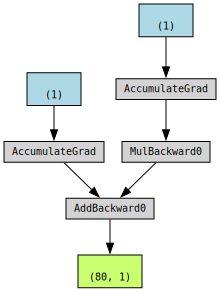

In [43]:
# 动态计算图可视化
# Step 0 - Initializes parameters "b" and "w" randomly
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)

# Step 1 - Computes our model's predicted output - forward pass
yhat = b + w * x_train_tensor

# Step 2 - Computes the loss
# We are using ALL data points, so this is BATCH gradient
# descent. How wrong is our model? That's the error! 
error = (yhat - y_train_tensor)
# It is a regression, so it computes mean squared error (MSE)
loss = (error ** 2).mean()

# We can try plotting the graph for any python variable: 
# yhat, error, loss...
make_dot(yhat)

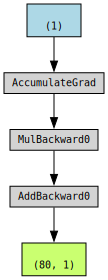

In [44]:
# 动态计算图只会包含需要求梯度的张量

b_nograd = torch.randn(1, requires_grad=False, \
                       dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)

yhat = b_nograd + w * x_train_tensor

make_dot(yhat)

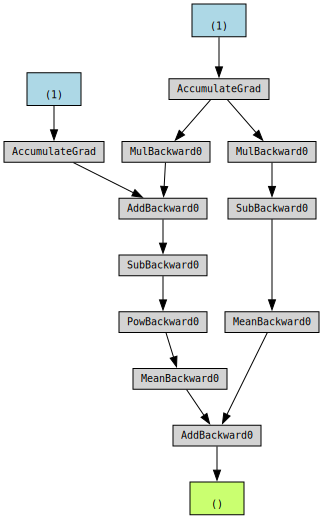

In [45]:
# 计算图可以复杂，可以有流程控制

b = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)

yhat = b + w * x_train_tensor
error = yhat - y_train_tensor
loss = (error ** 2).mean()

# this makes no sense!!
if loss > 0:
    yhat2 = w * x_train_tensor
    error2 = yhat2 - y_train_tensor
    
# neither does this :-)
loss += error2.mean()

make_dot(loss)

# 优化器

## step / zero_grad

In [46]:
# Defines a SGD optimizer to update the parameters
optimizer = optim.SGD([b, w], lr=lr)

### Cell 1.7 更新参数

到目前为止
- 初始化（torch手动）
- 每个epoch中
    - 预测(手动)
	- 计算损失（手动）
	- 计算梯度(torch计算图封装)
	- 更新参数(优化器封装)

In [47]:
# Sets learning rate - this is "eta" ~ the "n"-like Greek letter
lr = 0.1

# Step 0 - Initializes parameters "b" and "w" randomly
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)

# Defines a SGD optimizer to update the parameters
optimizer = optim.SGD([b, w], lr=lr)

# Defines number of epochs
n_epochs = 1000

for epoch in range(n_epochs):
    # Step 1 - Computes model's predicted output - forward pass
    yhat = b + w * x_train_tensor
    
    # Step 2 - Computes the loss
    # We are using ALL data points, so this is BATCH gradient 
    # descent. How wrong is our model? That's the error! 
    error = (yhat - y_train_tensor)
    # It is a regression, so it computes mean squared error (MSE)
    loss = (error ** 2).mean()

    # Step 3 - Computes gradients for both "b" and "w" parameters
    loss.backward()
    
    # Step 4 - Updates parameters using gradients and 
    # the learning rate. No more manual update!
    # with torch.no_grad():
    #     b -= lr * b.grad
    #     w -= lr * w.grad
    optimizer.step()
    
    # No more telling Pytorch to let gradients go!
    # b.grad.zero_()
    # w.grad.zero_()
    optimizer.zero_grad()
    
print(b, w)

tensor([1.0235], device='cuda:0', requires_grad=True) tensor([1.9690], device='cuda:0', requires_grad=True)


# 损失

In [48]:
# 定义MSE损失函数
# 注意返回的是函数
loss_fn = nn.MSELoss(reduction='mean')
loss_fn

MSELoss()

In [49]:
# 这是一个随机示例，用于说明损失函数
predictions = torch.tensor([0.5, 1.0])
labels = torch.tensor([2.0, 1.3])
loss_fn(predictions, labels)

tensor(1.1700)

### Cell 1.8 更新参数

到目前为止
- 初始化（torch函数）
- 每个epoch中
    - 预测(手动)
	- 计算损失（torch封装高阶函数 ）
	- 计算梯度(torch计算图封装)
	- 更新参数(优化器封装)

In [50]:
# Sets learning rate - this is "eta" ~ the "n"-like
# Greek letter
lr = 0.1

# Step 0 - Initializes parameters "b" and "w" randomly
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)

# Defines a SGD optimizer to update the parameters
optimizer = optim.SGD([b, w], lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# Defines number of epochs
n_epochs = 1000

for epoch in range(n_epochs):
    # Step 1 - Computes model's predicted output - forward pass
    yhat = b + w * x_train_tensor
    
    # Step 2 - Computes the loss
    # No more manual loss!
    # error = (yhat - y_train_tensor)
    # loss = (error ** 2).mean()
    loss = loss_fn(yhat, y_train_tensor)

    # Step 3 - Computes gradients for both "b" and "w" parameters
    loss.backward()
    
    # Step 4 - Updates parameters using gradients and
    # the learning rate
    optimizer.step()
    optimizer.zero_grad()
    
print(b, w)

tensor([1.0235], device='cuda:0', requires_grad=True) tensor([1.9690], device='cuda:0', requires_grad=True)


In [51]:
loss

tensor(0.0080, device='cuda:0', grad_fn=<MseLossBackward0>)

In [52]:
# RuntimeError: Can't call numpy() on Tensor
# that requires grad. Use tensor.detach().numpy() instead.
# loss.cpu().numpy()

In [53]:
loss.detach().cpu().numpy()

array(0.00804466, dtype=float32)

In [54]:
print(loss.item(), loss.tolist())

0.008044655434787273 0.008044655434787273


# 模型

### Cell 1.9 封装线性回归模型

In [55]:
# Module是torch神经网络包中的类

class ManualLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # To make "b" and "w" real parameters of the model,
        # we need to wrap them with nn.Parameter
        # 参数需要包装为nn.Parameter
        self.b = nn.Parameter(torch.randn(1,
                                          requires_grad=True, 
                                          dtype=torch.float))
        self.w = nn.Parameter(torch.randn(1, 
                                          requires_grad=True,
                                          dtype=torch.float))
    # 调用时直接使用类名，否则会丢失hook的调用
    def forward(self, x):
        # Computes the outputs / predictions
        return self.b + self.w * x

## 参数

In [56]:
# 查看模型参数

torch.manual_seed(42)
# Creates a "dummy" instance of our ManualLinearRegression model
dummy = ManualLinearRegression()
list(dummy.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

## state_dict: 所有参数的当前值

In [57]:
dummy.state_dict()

OrderedDict([('b', tensor([0.3367])), ('w', tensor([0.1288]))])

In [58]:
optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.1,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1]}]}

## 设备

In [59]:
torch.manual_seed(42)
# Creates a "dummy" instance of our ManualLinearRegression model
# and sends it to the device
# 模型也要存在于设备上才能计算GPU张量
dummy = ManualLinearRegression().to(device)

## 前向传播

### Cell 1.10

到目前为止
- 初始化（封装进了torch模型类）
- 每个epoch中
    - 预测(封装进了torch模型类)
	- 计算损失（torch封装高阶函数）
	- 计算梯度(torch计算图封装)
	- 更新参数(优化器封装)

In [60]:
# Sets learning rate - this is "eta" ~ the "n"-like
# Greek letter
lr = 0.1

# Step 0 - Initializes parameters "b" and "w" randomly
torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = ManualLinearRegression().to(device)

# Defines a SGD optimizer to update the parameters 
# (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# Defines number of epochs
n_epochs = 1000

for epoch in range(n_epochs):
    # 设置模型为训练模式
    model.train() # What is this?!?

    # Step 1 - Computes model's predicted output - forward pass
    # No more manual prediction!
    yhat = model(x_train_tensor)
    
    # Step 2 - Computes the loss
    loss = loss_fn(yhat, y_train_tensor)

    # Step 3 - Computes gradients for both "b" and "w" parameters
    loss.backward()
    
    # Step 4 - Updates parameters using gradients and
    # the learning rate
    optimizer.step()
    optimizer.zero_grad()
    
# We can also inspect its parameters using its state_dict
print(model.state_dict())

OrderedDict([('b', tensor([1.0235], device='cuda:0')), ('w', tensor([1.9690], device='cuda:0'))])


## train

In [61]:
## 千万别忘了在训练循环中包含 model.train()！

## 嵌套模型

In [62]:
# Torch自带的神经网络线性回归模型
# 只用指定输入和输出的维度即可
# 注意返回的是类
linear = nn.Linear(1, 1)
linear

Linear(in_features=1, out_features=1, bias=True)

In [63]:
linear.state_dict()

OrderedDict([('weight', tensor([[-0.2191]])), ('bias', tensor([0.2018]))])

### Cell 1.11 封装线性回归模型

到目前为止
- 初始化（封装进了torch模型类）
- 每个epoch中
    - 预测(封装进了torch模型类)
	- 计算损失（torch封装高阶函数）
	- 计算梯度(torch计算图封装)
	- 更新参数(优化器封装)
进一步的
- 将torch模型类封装进我们的模型类中

In [64]:
class MyLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # Instead of our custom parameters, we use a Linear model
        # with single input and single output
        self.linear = nn.Linear(1, 1)
                
    def forward(self, x):
        # Now it only takes a call
        self.linear(x)

In [65]:
torch.manual_seed(42)
dummy = MyLinearRegression().to(device)
list(dummy.parameters())

[Parameter containing:
 tensor([[0.7645]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.8300], device='cuda:0', requires_grad=True)]

In [66]:
dummy.state_dict()

OrderedDict([('linear.weight', tensor([[0.7645]], device='cuda:0')),
             ('linear.bias', tensor([0.8300], device='cuda:0'))])

## 序列模型（层的抽象）

### Cell 1.12 构建序列模型

In [67]:
torch.manual_seed(42)
# Alternatively, you can use a Sequential model
model = nn.Sequential(nn.Linear(1, 1)).to(device)

model.state_dict()

OrderedDict([('0.weight', tensor([[0.7645]], device='cuda:0')),
             ('0.bias', tensor([0.8300], device='cuda:0'))])

## 层（层抽象）

In [68]:
torch.manual_seed(42)
# Building the model from the figure above
model = nn.Sequential(nn.Linear(3, 5), nn.Linear(5, 1)).to(device)

model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4414,  0.4792, -0.1353],
                      [ 0.5304, -0.1265,  0.1165],
                      [-0.2811,  0.3391,  0.5090],
                      [-0.4236,  0.5018,  0.1081],
                      [ 0.4266,  0.0782,  0.2784]], device='cuda:0')),
             ('0.bias',
              tensor([-0.0815,  0.4451,  0.0853, -0.2695,  0.1472], device='cuda:0')),
             ('1.weight',
              tensor([[-0.2060, -0.0524, -0.1816,  0.2967, -0.3530]], device='cuda:0')),
             ('1.bias', tensor([-0.2062], device='cuda:0'))])

In [69]:
# 添加层名字

torch.manual_seed(42)
# Building the model from the figure above
model = nn.Sequential()
model.add_module('layer1', nn.Linear(3, 5))
model.add_module('layer2', nn.Linear(5, 1))
model.to(device)

Sequential(
  (layer1): Linear(in_features=3, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

# 汇集一炉！
1. 数据准备
2. 模型配置
3. 模型训练

## 数据准备

### Data Preparation V0
这里涉及notebook的两个特殊命令
- writefile
- run

一个是将单元格内容昔日如文件

一个是运行文件(同时将当前notebook中的变量传递给文件中的代码)

In [70]:
%%writefile data_preparation/v0.py

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 传递数据
# Our data was in Numpy arrays, but we need to transform them
# into PyTorch's Tensors and then we send them to the 
# chosen device
x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

Overwriting data_preparation/v0.py


In [71]:
%run -i data_preparation/v0.py

## 模型配置

### Model Configuration V0

In [72]:
%%writefile model_configuration/v0.py

# This is redundant now, but it won't be when we introduce
# Datasets...
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sets learning rate - this is "eta" ~ the "n"-like Greek letter
# 超参数：学习率lr
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
# 模型
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters 
# (now retrieved directly from the model)
# 优化器
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
# 损失函数
loss_fn = nn.MSELoss(reduction='mean')

Overwriting model_configuration/v0.py


In [73]:
%run -i model_configuration/v0.py

## 模型训练

### Model Training V0

In [74]:
%%writefile model_training/v0.py

# Defines number of epochs
# 定义周期
n_epochs = 1000

# 更新参数
for epoch in range(n_epochs):
    # Sets model to TRAIN mode
    model.train()

    # Step 1 - Computes model's predicted output - forward pass
    yhat = model(x_train_tensor)
    
    # Step 2 - Computes the loss
    loss = loss_fn(yhat, y_train_tensor)

    # Step 3 - Computes gradients for both "b" and "w" parameters
    loss.backward()
    
    # Step 4 - Updates parameters using gradients and 
    # the learning rate
    optimizer.step()
    optimizer.zero_grad()

Overwriting model_training/v0.py


In [75]:
%run -i model_training/v0.py

In [76]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9690]], device='cuda:0')), ('0.bias', tensor([1.0235], device='cuda:0'))])
